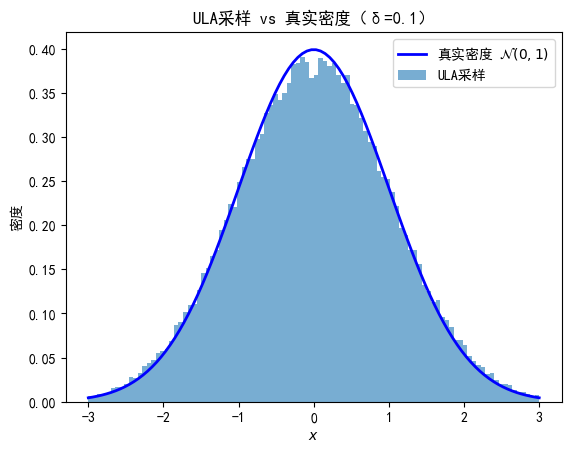

δ=0.1: 经验方差=1.046551, 理论方差=1.052632
#####
δ=1: 经验方差=1.999389, 理论方差=2.000000

渐近方差公式验证：Var_ULA = 2/(2-delta)
------------------------------------------------------------
δ=0.01: 经验方差=1.025479, 理论方差=1.005025
δ=0.05: 经验方差=1.056565, 理论方差=1.025641
δ=0.1: 经验方差=1.044409, 理论方差=1.052632
δ=0.2: 经验方差=1.108195, 理论方差=1.111111
δ=0.5: 经验方差=1.339573, 理论方差=1.333333
δ=1.0: 经验方差=2.000308, 理论方差=2.000000


In [1]:
"""
实验4.1 1D高斯ULA采样与渐近方差验证
对应章节：4.3（ULA递推式、渐近方差、偏差）
素材来源：Mathematics.../Teaching Unit 2/labs/lab1_ULA_sol.ipynb
  - ULA_gauss() 函数
  - var_compare() 函数
  - 1D实验代码（ULA直方图 vs 真实密度）
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
# 1. 彻底屏蔽 matplotlib 的字体警告日志
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 2. 忽略 Python 层面的相关 UserWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")

# 3. 强制使用 ASCII 减号（连字符）替代 Unicode 减号（U+2212），并设置中文字体
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

np.random.seed(42)

# ============================================================
# ULA_gauss 函数（取自 lab1_ULA_sol.ipynb）
# 从1D标准高斯 N(0,1) 中用ULA采样
# 势能 U(x)=x²/2, ∇U(x)=x
# ULA: X_{m+1} = X_m - δ·∇U(X_m) + √(2δ)·Z_{m+1}
#                  = (1-δ)·X_m + √(2δ)·Z_{m+1}
# ============================================================
def ULA_gauss(niter, delta, x0=0):
    Y = np.zeros(niter,)
    X = x0
    for i in range(niter):
        Z = np.random.randn()
        grad = X
        X = X - delta*grad + np.sqrt(2*delta)*Z
        Y[i] = X
    return Y, np.var(Y)


# ============================================================
# 实验1：ULA直方图 vs 真实密度（取自 lab1_ULA_sol 的1D实验代码）
# ============================================================
x0 = 0
niter = int(1e5)
delta = 0.1

Y, _ = ULA_gauss(niter, delta, x0)

# 显示高斯分布（蓝色曲线）
x = np.linspace(-3, 3, 100)
y = 1/(np.sqrt(2*np.pi))*np.exp(-x**2 / 2)
plt.plot(x, y, 'b-', linewidth=2, label='真实密度 $\\mathcal{N}(0,1)$')

# 显示ULA采样直方图
plt.hist(Y, bins=100, range=[-3, 3], density=1, alpha=0.6, label='ULA采样')
plt.xlabel('$x$')
plt.ylabel('密度')
plt.title(f'ULA采样 vs 真实密度（δ={delta}）')
plt.legend()
plt.savefig('实验4_1_ULA直方图.png', dpi=150)
plt.show()


# ============================================================
# 实验2：渐近方差验证（取自 lab1_ULA_sol 的 var_compare 函数）
# 理论渐近方差 Var_ULA = 2/(2-δ)
# ============================================================
def var_compare(delta):
    _, var1 = ULA_gauss(int(1e5), delta, x0=0)
    var2 = 2/(2-delta)
    print(f"δ={delta}: 经验方差={var1:.6f}, 理论方差={var2:.6f}")

var_compare(0.1)
print('#####')
var_compare(1)

print("\n渐近方差公式验证：Var_ULA = 2/(2-delta)")
print("-" * 60)
for d in [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]:
    var_compare(d)
